In [1]:
import numpy as np
import matplotlib.pyplot as plt
from model.bioreactor import ideal_Bioreactor, real_Bioreactor
from estimation.ekf import EKF
from parameters import Parameters
from ipywidgets import *

In [2]:
params = Parameters()
bioreactor_params = params.get_bioreactor_params()
ekf_params = params.get_ekf_params()
grid_params = params.get_grid_params()

time_steps = 24000 # number of time steps to simulate (2.4 hours)
dt = 0.001 # hours

In [3]:
bioreactor = ideal_Bioreactor(bioreactor_params)
ekf = EKF(bioreactor, ekf_params)

def F(t):
    return  0.1 #100 * abs(np.sin(2 * np.pi * t / 24)) # example feed rate function (sinusoidal)

In [4]:
true_states = []
estimated_states = []
measurements = []
true_states.append(bioreactor.state.copy())
estimated_states.append(ekf.state.copy())
measurements.append(bioreactor.get_measurement(bioreactor.state))
for i in range(time_steps):
    F_t = F(i * dt)
    true_states.append(bioreactor.update(F_t, dt))
    estimated_states.append(ekf.step(F_t, dt))
    measurements.append(bioreactor.get_measurement(bioreactor.state))
true_states = np.array(true_states)
estimated_states = np.array(estimated_states)
measurements = np.array(measurements)


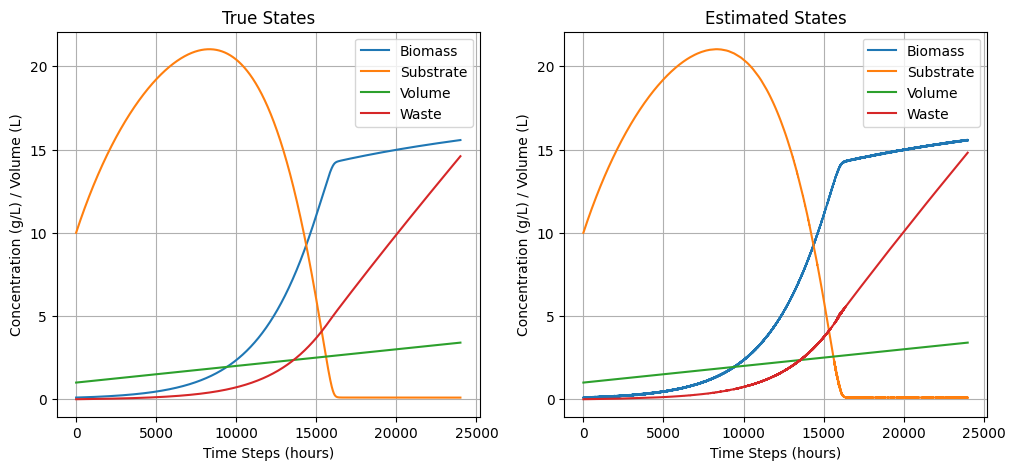

In [5]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(true_states, label=['Biomass', 'Substrate', 'Volume', 'Waste'])
plt.xlabel('Time Steps (hours)')
plt.ylabel('Concentration (g/L) / Volume (L)')
plt.grid()
plt.legend()
plt.title('True States')
plt.subplot(1, 2, 2)
plt.plot(estimated_states, label=['Biomass', 'Substrate', 'Volume', 'Waste'])
plt.xlabel('Time Steps (hours)')
plt.ylabel('Concentration (g/L) / Volume (L)')
plt.grid()
plt.title('Estimated States')
plt.legend()

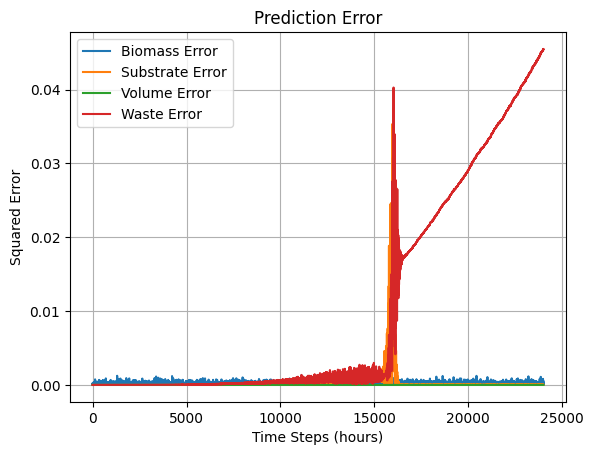

In [6]:
plt.plot((true_states - estimated_states) ** 2, label=['Biomass Error', 'Substrate Error', 'Volume Error', 'Waste Error'])
plt.xlabel('Time Steps (hours)')
plt.ylabel('Squared Error')
plt.grid()
plt.title('Prediction Error')
plt.legend()

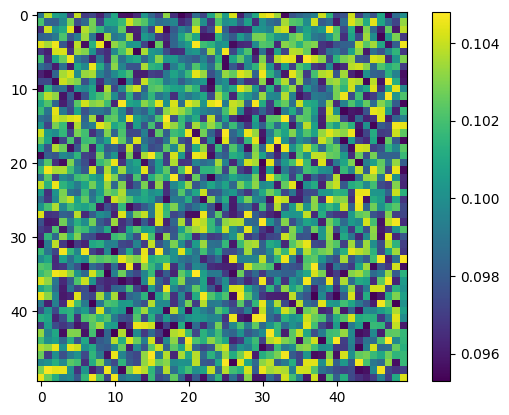

In [7]:
real_bioreactor = real_Bioreactor(bioreactor_params, grid_params)
plt.imshow(real_bioreactor.X_grid)
plt.colorbar()

In [8]:
ekf = EKF(real_bioreactor, ekf_params)
true_states = []
X_grids = []
S_grids = []
estimated_states = []
true_states.append(real_bioreactor.state.copy())
X_grids.append(real_bioreactor.X_grid.copy())
S_grids.append(real_bioreactor.S_grid.copy())
estimated_states.append(ekf.state.copy())
for i in range(time_steps):
    F_alt = 0.1
    real_bioreactor.update(F_alt, dt)
    estimated_states.append(ekf.step(F_alt, dt))
    true_states.append(real_bioreactor.state.copy())
    X_grids.append(real_bioreactor.X_grid.copy())
    S_grids.append(real_bioreactor.S_grid.copy())
measurements = np.array(measurements)
true_states = np.array(true_states)
X_grids = np.array(X_grids)
S_grids = np.array(S_grids)
history = {'biomass': X_grids, 'substrate': S_grids}

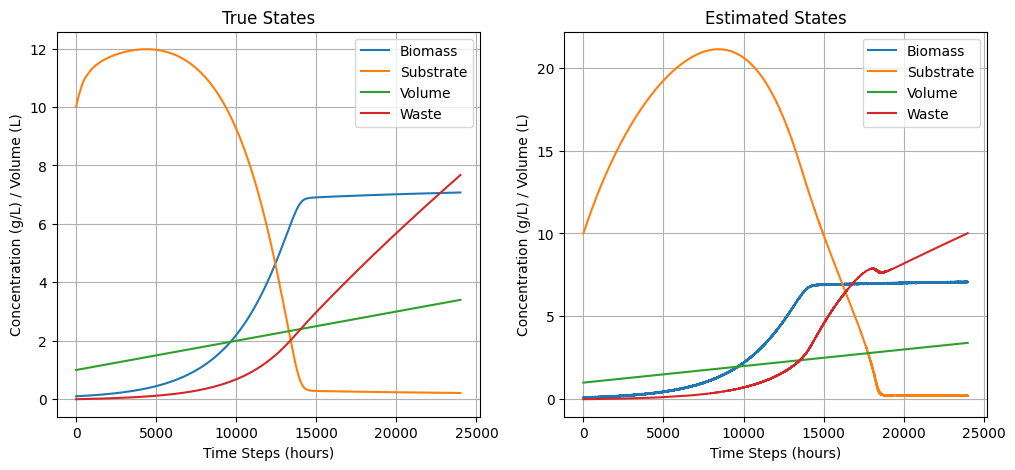

In [9]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(true_states, label=['Biomass', 'Substrate', 'Volume', 'Waste'])
plt.xlabel('Time Steps (hours)')
plt.ylabel('Concentration (g/L) / Volume (L)')
plt.grid()
plt.legend()
plt.title('True States')
plt.subplot(1, 2, 2)
plt.plot(estimated_states, label=['Biomass', 'Substrate', 'Volume', 'Waste'])
plt.xlabel('Time Steps (hours)')
plt.ylabel('Concentration (g/L) / Volume (L)')
plt.grid()
plt.title('Estimated States')
plt.legend()

In [10]:
def plotter(timestep, history):
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(history['biomass'][timestep], cmap='inferno')
    plt.title(f'Biomass at Timestep {timestep}')
    plt.colorbar(label='Biomass Concentration')
    plt.subplot(1, 2, 2)
    plt.imshow(history['substrate'][timestep], cmap='inferno')
    plt.title(f'Substrate at Timestep {timestep}')
    plt.colorbar(label='Substrate Concentration')
    plt.show()

interactive(plotter, timestep = Play(min=0, max=time_steps, value=0, interval=20),
             history=fixed(history))

interactive(children=(Play(value=0, description='timestep', interval=20, max=24000), Output()), _dom_classes=(…